# EDA — Pib Demanda

---
## 0. Configuración del Dataset

In [30]:
# ============================================================
# CONFIGURACIÓN: PIB_DEMANDA
# ============================================================

DATASET_CONFIG = {
    'nombre': 'pib_demanda',
    'archivo': 'pib_demanda_constantes_2025_1970_2026.csv',
    'frecuencia_original': 'trimestral',
    'col_fecha': 'fecha',
    'variable_principal': 'pib_pm',
    'variables_desgloses': [
        'consumo_privado_nacional',
        'consumo_publico',
        'fbcf',
        'exportacion_bienes_servicios',
        'importacion_bienes_servicios',
    ],
    'columnas_numericas': [
        'pib_pm',
        'demanda_nacional',
        'consumo_privado_nacional',
        'consumo_privado_interior',
        'consumo_publico',
        'fbcf',
        'variacion_existencias',
        'exportacion_bienes_servicios',
        'exportacion_bienes',
        'exportacion_servicios',
        'importacion_bienes_servicios',
        'importacion_bienes',
        'importacion_servicios',
    ],
    'unidades': 'millones EUR (precios constantes 2025)',
    'notas': 'INE, CNT. PIB por el lado de la demanda. Precios constantes 2025. Trimestral 1970Q1–2026Q1.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: pib_demanda
Variable principal:  pib_pm
Frecuencia:          trimestral
Periodo estacional:  4


---
## Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}
EVENTOS['1993-01-01'] = 'Recesión\n93'
EVENTOS['2009-01-01'] = 'Mín PIB\n09'

---
## 1. Carga y Diagnóstico Básico

In [32]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: pib_demanda
Notas:   INE, CNT. PIB por el lado de la demanda. Precios constantes 2025. Trimestral 1970Q1–2026Q1.
Shape:          (206, 20)
Rango temporal: 1974-07-01 a 2025-10-01
Observaciones:  206
Columnas:       ['año', 'trimestre', 'pib_pm', 'demanda_nacional', 'consumo_privado_nacional', 'consumo_privado_interior', 'consumo_publico', 'fbcf', 'variacion_existencias', 'exportacion_bienes_servicios', 'exportacion_bienes', 'exportacion_servicios', 'importacion_bienes_servicios', 'importacion_bienes', 'importacion_servicios', 'tasa_inversion', 'apertura_comercial', 'saldo_comercial_pct_pib', 'consumo_publico_pct_pib', 'pib_index_base']


In [33]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,trimestre,pib_pm,demanda_nacional,consumo_privado_nacional,consumo_privado_interior,consumo_publico,fbcf,variacion_existencias,exportacion_bienes_servicios,exportacion_bienes,exportacion_servicios,importacion_bienes_servicios,importacion_bienes,importacion_servicios,tasa_inversion,apertura_comercial,saldo_comercial_pct_pib,consumo_publico_pct_pib,pib_index_base
fecha,,,,,,,,,,,,,,,,,,,,
1974-07-01,1974,3,141251.708,149259.397,92087.287,96565.630,14029.979,40002.207,3139.924,20456.402,12310.035,3116.343,28464.090,26545.542,1366.868,28.320,34.634,-5.669,9.933,100.000
1974-10-01,1974,4,141345.166,148955.485,92136.493,96559.044,14181.234,39501.899,3135.859,20515.034,12395.603,3157.037,28125.352,26255.007,1330.503,27.947,34.412,-5.384,10.033,100.066
1975-01-01,1975,1,140635.732,146854.122,91134.577,95565.144,14275.168,38454.540,2989.838,19890.563,11732.062,3181.564,26108.954,24298.580,1264.003,27.343,32.708,-4.422,10.150,99.564



Últimas 3 filas:


,año,trimestre,pib_pm,demanda_nacional,consumo_privado_nacional,consumo_privado_interior,consumo_publico,fbcf,variacion_existencias,exportacion_bienes_servicios,exportacion_bienes,exportacion_servicios,importacion_bienes_servicios,importacion_bienes,importacion_servicios,tasa_inversion,apertura_comercial,saldo_comercial_pct_pib,consumo_publico_pct_pib,pib_index_base
fecha,,,,,,,,,,,,,,,,,,,,
2025-04-01,2025,2,423911.624,403022.157,232474.096,245138.417,82036.068,86843.921,714.315,160537.627,102983.642,57553.984,139648.159,112343.879,27304.280,20.486,70.813,4.928,19.352,300.111
2025-07-01,2025,3,420217.852,400312.148,234482.393,252000.380,76206.172,86888.856,1722.948,158257.054,93060.401,65196.653,138351.350,108242.119,30109.231,20.677,70.584,4.737,18.135,297.496
2025-10-01,2025,4,437461.025,424535.151,235617.557,241791.138,90186.908,91488.040,5789.067,150099.189,95427.363,54671.826,137173.315,107194.841,29978.473,20.913,65.668,2.955,20.616,309.703


In [34]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
pib_pm,0,0.000,1974-07-01,2025-10-01
demanda_nacional,0,0.000,1974-07-01,2025-10-01
consumo_privado_nacional,0,0.000,1974-07-01,2025-10-01
consumo_privado_interior,0,0.000,1974-07-01,2025-10-01
consumo_publico,0,0.000,1974-07-01,2025-10-01
fbcf,0,0.000,1974-07-01,2025-10-01
variacion_existencias,0,0.000,1974-07-01,2025-10-01
exportacion_bienes_servicios,0,0.000,1974-07-01,2025-10-01
exportacion_bienes,0,0.000,1974-07-01,2025-10-01
exportacion_servicios,0,0.000,1974-07-01,2025-10-01



Duplicados de fecha: 0


In [35]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 92 days 00:00:00
Intervalo mínimo:                      90 days 00:00:00
Intervalo máximo:                      92 days 00:00:00


---
## 2. Series Temporales

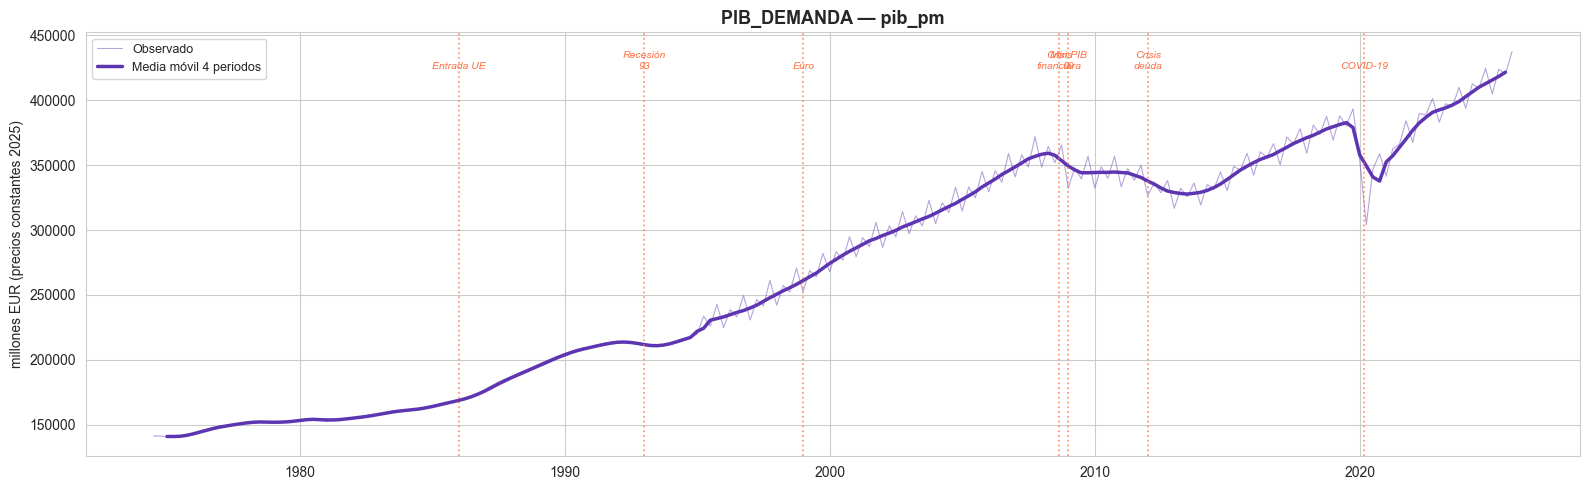

Mín: 140518.91  (1975-04-01)
Máx: 437461.02  (2025-10-01)


In [36]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

El `pib_pm` (PIB a precios de mercado en millones de euros constantes de 2025) describe la trayectoria de crecimiento económico real de España desde un mínimo de 140.519 millones en el segundo trimestre de 1975 hasta un máximo histórico de 437.461 millones en el cuarto trimestre de 2025, multiplicando el nivel real de producción por un factor de aproximadamente 3,1 a lo largo de cinco décadas.

La serie presenta tendencia ascendente dominante con tres interrupciones cíclicas claramente identificables. La primera, entre 1992 y 1994, corresponde a la crisis del SME y las devaluaciones de la peseta: el PIB se estabiliza en torno a 210.000 millones antes de retomar el crecimiento. La segunda y más severa, entre 2008 y 2013, refleja la combinación de la crisis financiera global y el estallido de la burbuja inmobiliaria: el PIB cae desde aproximadamente 360.000 millones hasta aproximadamente 330.000 millones, una contracción de aproximadamente el 8% en términos reales que tarda casi una década en recuperarse. La tercera, en 2020, es la más abrupta en términos de velocidad: el confinamiento del segundo trimestre de 2020 produce la caída más vertical de toda la muestra, desde aproximadamente 380.000 hasta aproximadamente 310.000 millones en un único trimestre, seguida de una recuperación igualmente rápida que lleva al PIB a máximos históricos en 2022-2025.

La diferencia entre la serie observada y la media móvil de 4 periodos es mínima salvo en el entorno de 2020, donde la volatilidad intra-anual del confinamiento produce la única divergencia visible entre ambas. Fuera de ese episodio, la estacionalidad trimestral del PIB es prácticamente nula a escala visual, lo que se confirmará en el análisis de descomposición. Para la modelización del paro, el PIB es la variable con mayor fundamentación teórica como predictor a través de la Ley de Okun: variaciones del crecimiento real por encima o por debajo del potencial se traducen en variaciones de la tasa de paro en sentido opuesto, con un multiplicador que la literatura estima para España en torno a 0,3-0,5 puntos de paro por punto porcentual de brecha del producto.

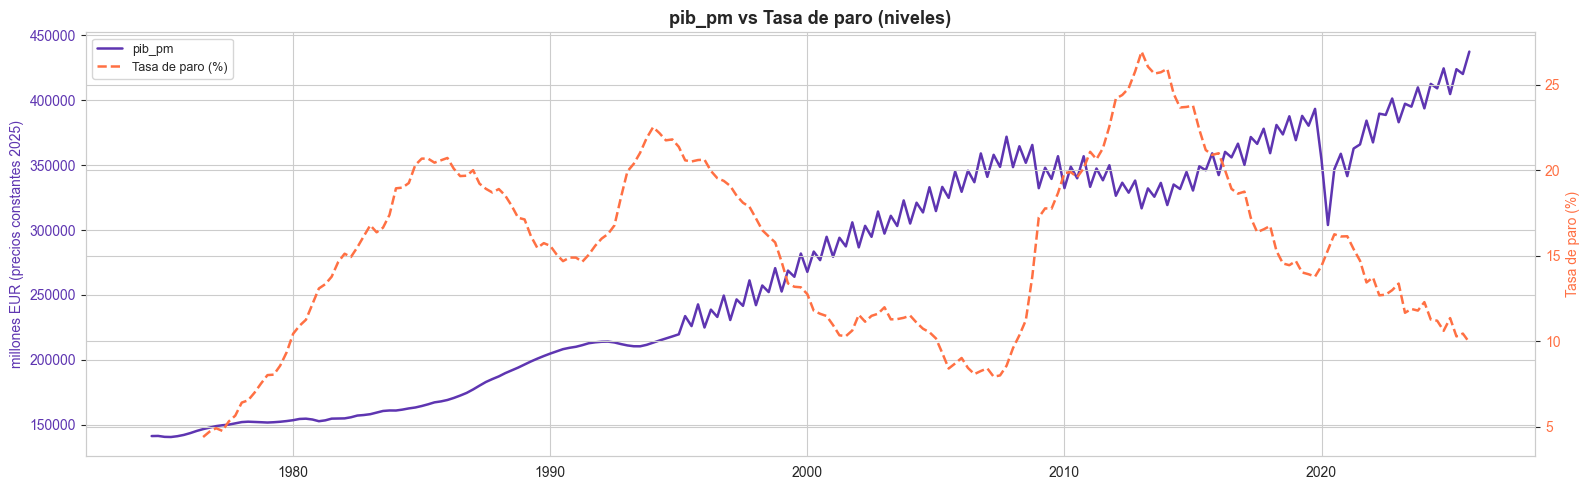

In [37]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La relación en niveles entre el `pib_pm` y la tasa de paro está dominada por la tendencia del PIB, no por una relación contemporánea estable. El PIB describe una trayectoria ascendente casi monótona, con la estacionalidad trimestral visible como zigzag, desde aproximadamente 141.000 millones en 1975 hasta 437.000 millones en 2025, mientras la tasa de paro carece de tendencia y recorre tres grandes ciclos (picos de aproximadamente 21% en 1985, 24% en 1994 y 27% en 2013, con un mínimo del 8% en 2007 y descenso final al 10%). Como una serie crece de forma sostenida y la otra oscila sin tendencia, el signo de la relación en niveles depende del tramo: positivo en 1975-1985 cuando ambas suben, claramente inverso entre 1994 y 2007 con el PIB al alza y el paro a la baja, y de nuevo inverso en la Gran Recesión, cuando el PIB se estanca y cae mientras el paro escala hasta el 27%. Esta deriva común enmascara la relación cíclica y haría espuria cualquier correlación en niveles; el análisis cuantitativo se realiza en la sección 9 sobre la forma estacionaria, la variación interanual del PIB, donde emerge la Ley de Okun.

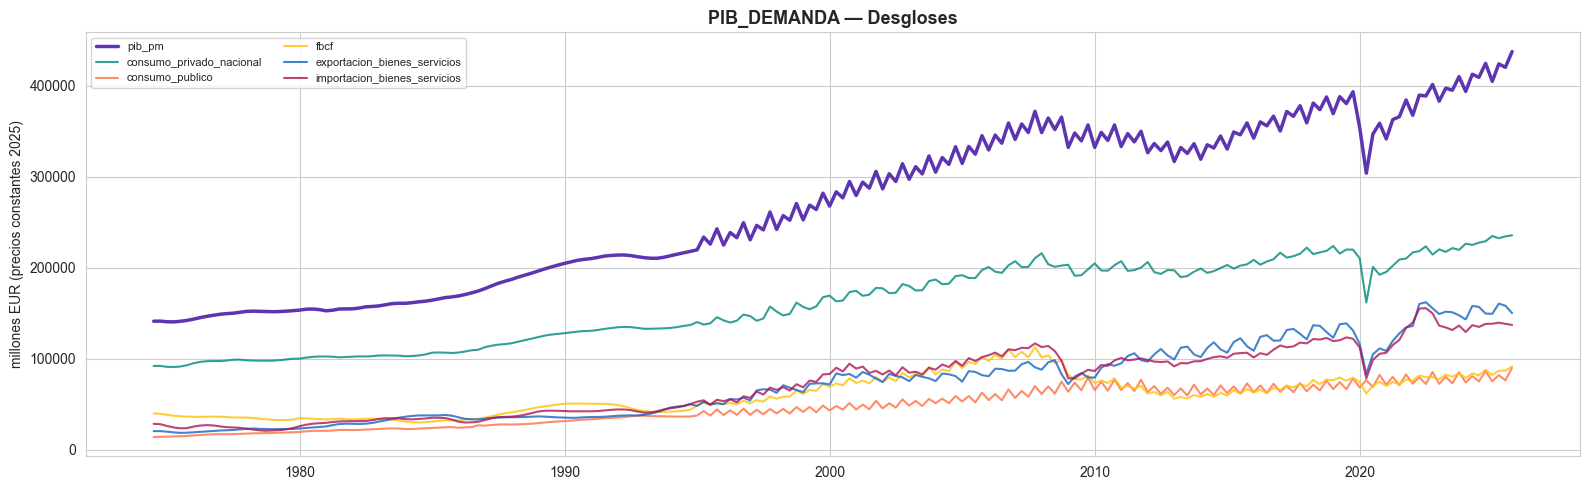

In [38]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=2.5, label=VAR_PRINCIPAL, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(UNIDADES, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

El desglose por componentes de demanda revela que el `consumo_privado_nacional` es el componente de mayor peso y el que más contribuye a la trayectoria del `pib_pm`, siguiendo una evolución paralela al agregado con un nivel que oscila entre aproximadamente 91.600 millones en 1975 y 234.000 millones en 2025. Su perfil de crecimiento es el más suave de todos los componentes, con caídas moderadas en las tres recesiones y una recuperación gradual en todas ellas, lo que refleja la inercia característica del consumo de los hogares frente a perturbaciones cíclicas.

`exportacion_bienes_servicios` e `importacion_bienes_servicios` forman un par que hasta aproximadamente 1995 se mueve en una banda baja y estrecha (aproximadamente 19.000-50.000 millones cada una), y a partir de la segunda mitad de los 90 crece de forma acelerada hasta situarse ambas en torno a 100.000-150.000 millones en 2025. Esta expansión simétrica refleja la creciente apertura de la economía española tras la integración en el mercado único europeo y la adopción del euro, que eliminó los costes de transacción cambiarios con los socios comerciales principales. El hecho de que exportaciones e importaciones crezcan a ritmos similares implica que su contribución neta al PIB (exportaciones menos importaciones) es relativamente estable a lo largo del tiempo, aunque en las recesiones de 2009-2013 y 2020 las importaciones caen más rápido que las exportaciones, mejorando temporalmente el saldo exterior.

`fbcf` (formación bruta de capital fijo) es el componente más volátil y el que concentra la mayor parte del ajuste en los ciclos. Su caída entre 2008 y 2013, desde aproximadamente 110.000 hasta aproximadamente 60.000 millones, es proporcionalmente la más severa de todos los componentes y refleja el colapso de la inversión en construcción residencial tras el estallido de la burbuja inmobiliaria. Esta característica convierte a la `fbcf` en el componente del PIB con mayor correlación potencial con la tasa de paro, dado que el sector de la construcción concentraba una fracción desproporcionada del empleo en el ciclo 2000-2008 y su destrucción explica gran parte del shock de desempleo de la Gran Recesión. El `consumo_publico` describe la trayectoria más estable de todos los componentes, con crecimiento gradual y sostenido que actúa como estabilizador automático en las recesiones, siendo el único componente que no cae en 2009.

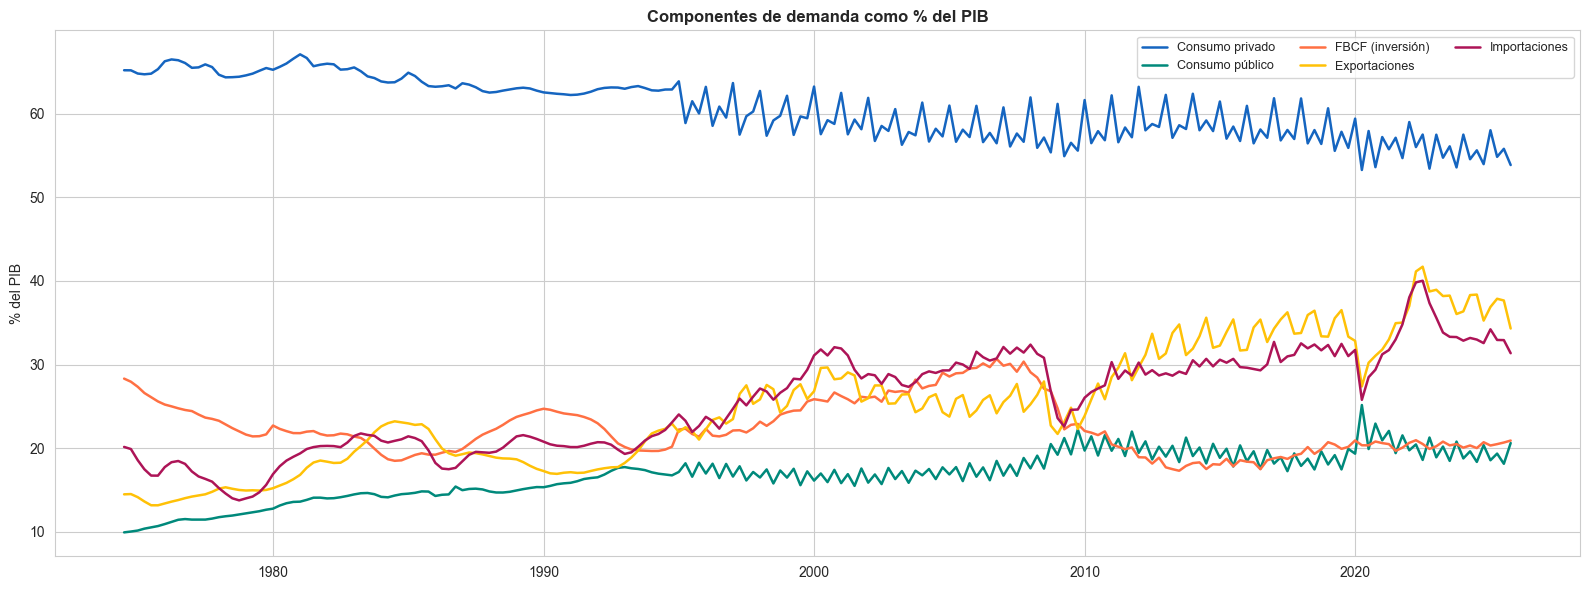

In [39]:
# Participación de componentes de demanda en el PIB
componentes_pib = {
    'Consumo privado': 'consumo_privado_nacional',
    'Consumo público': 'consumo_publico',
    'FBCF (inversión)': 'fbcf',
    'Exportaciones': 'exportacion_bienes_servicios',
    'Importaciones': 'importacion_bienes_servicios',
}
cols_pib = {k: v for k, v in componentes_pib.items() if v in df.columns}

if cols_pib and 'pib_pm' in df.columns:
    df_shares = df[list(cols_pib.values())].div(df['pib_pm'], axis=0) * 100
    df_shares.columns = list(cols_pib.keys())

    fig, ax = plt.subplots(figsize=(16, 6))
    for col, color in zip(df_shares.columns, ['#1565C0', '#00897B', '#FF7043', '#FFC107', '#AD1457']):
        ax.plot(df_shares.index, df_shares[col], lw=1.8, label=col, color=color)

    ax.set_title('Componentes de demanda como % del PIB', fontsize=12, fontweight='bold')
    ax.set_ylabel('% del PIB', fontsize=10)
    ax.legend(fontsize=9, ncol=3)
    plt.tight_layout()
    plt.show()

### Análisis:

La composición de la demanda como porcentaje del PIB revela transformaciones estructurales de largo plazo que el análisis en niveles absolutos no permite apreciar con claridad.

El consumo privado domina la estructura de demanda durante toda la muestra pero describe una tendencia descendente continua, desde aproximadamente 65% del PIB en 1975 hasta aproximadamente 54% en 2025. Esta reducción de 11 puntos porcentuales en cinco décadas no refleja una caída del consumo en términos reales, sino la expansión relativa de los demás componentes, en particular del sector exterior. El consumo público describe la trayectoria opuesta: sube desde aproximadamente 10% en 1975 hasta aproximadamente 20% en los años 90, donde se estabiliza, consolidando el desarrollo del Estado del bienestar español durante la Transición y la integración europea.

La transformación más llamativa es la del sector exterior. Exportaciones e importaciones partían de niveles inferiores al 15-20% del PIB en 1975 y han escalado hasta el 35-40% al final de la muestra, cruzándose con la FBCF en torno a 2000 y convirtiéndose en los componentes de mayor dinamismo relativo de la economía española. Esta apertura refleja la integración en el mercado único, la adopción del euro y la especialización en turismo y servicios exportables. El cruce entre exportaciones e importaciones en torno a 2009-2010 es particularmente informativo: las importaciones caen más rápidamente que las exportaciones durante la Gran Recesión, mejorando el saldo exterior y compensando parcialmente la caída de la demanda interna.

La FBCF describe el ciclo más dramático en términos de participación relativa: sube desde aproximadamente 22% en 1975 hasta aproximadamente 31% en 2007, impulsada por la burbuja de inversión inmobiliaria, y cae hasta aproximadamente 18% en 2013-2014, su nivel más bajo de la muestra. Esta oscilación de 13 puntos porcentuales en menos de una década es la mayor de cualquier componente y cuantifica la magnitud del desajuste inversor del ciclo 2000-2013. Para la modelización del paro, este gráfico refuerza la relevancia de la FBCF como indicador adelantado: los ciclos de inversión, especialmente en construcción, son el mecanismo de transmisión principal entre el ciclo del PIB y el mercado laboral español.

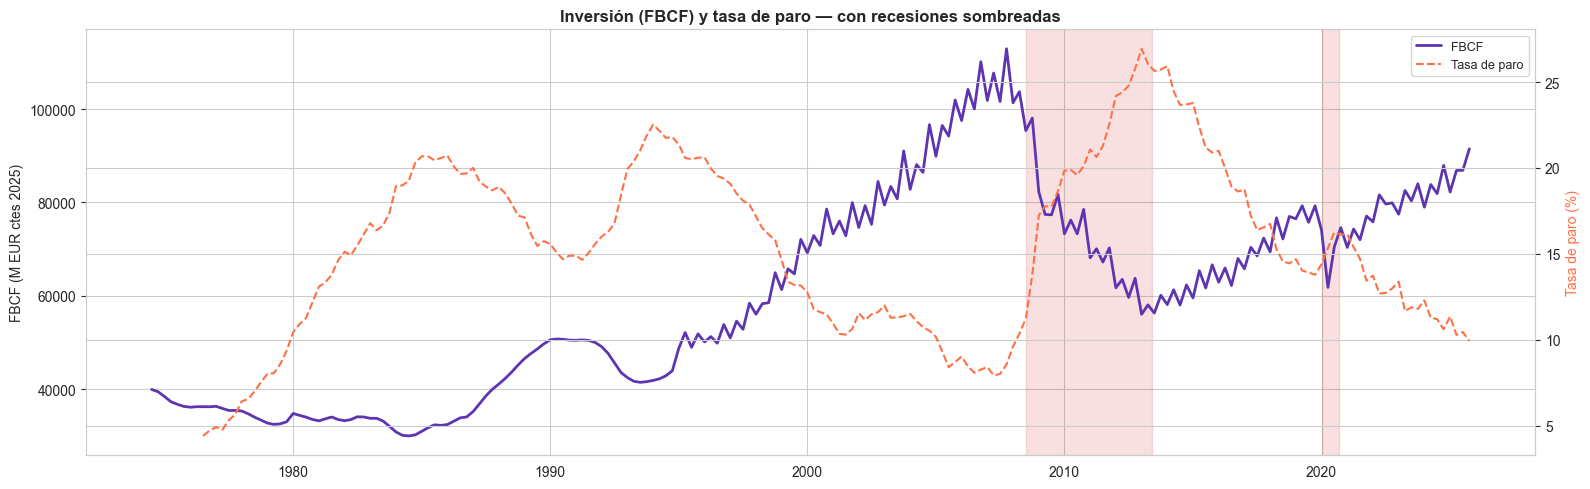

In [40]:
# FBCF (inversión) con sombreado de recesiones y parados en eje secundario
if 'fbcf' in df.columns:
    ruta_parados_pib = RUTA_BASE / 'parados_sexo_edad.csv'
    df_par_pib = pd.read_csv(ruta_parados_pib)
    df_par_pib['fecha'] = pd.to_datetime(df_par_pib['fecha'])
    df_par_pib = df_par_pib.set_index('fecha').sort_index()

    fig, ax1 = plt.subplots(figsize=(16, 5))
    ax1.plot(df['fbcf'].index, df['fbcf'], color=COLOR_PRINCIPAL, lw=2, label='FBCF')

    # Sombreado de recesiones
    recesiones = [('2008-07-01', '2013-06-01'), ('2020-01-01', '2020-09-01')]
    for inicio, fin in recesiones:
        ax1.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin), alpha=0.15, color='#D32F2F')

    ax2 = ax1.twinx()
    par_serie = pd.to_numeric(df_par_pib['tasa_paro_ambos_sexos_total'], errors='coerce')
    ax2.plot(par_serie.index, par_serie, color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro')
    ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)

    ax1.set_title('Inversión (FBCF) y tasa de paro — con recesiones sombreadas', fontsize=12, fontweight='bold')
    ax1.set_ylabel('FBCF (M EUR ctes 2025)', fontsize=10)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
    plt.tight_layout()
    plt.show()

### Análisis:

La FBCF y la tasa de paro describen una relación inversa visualmente clara y consistente a lo largo de casi toda la muestra, confirmando el papel central de la inversión como mecanismo de transmisión entre el ciclo económico y el mercado laboral español.

El periodo 1975-1994 muestra la relación más directa: mientras la FBCF se mantiene estancada entre 30.000 y 50.000 millones, el paro asciende desde 4% hasta 24%, reflejando que la ausencia de dinamismo inversor durante la reconversión industrial y la crisis del SME no generó capacidad de absorción de la fuerza laboral creciente. La recuperación de la FBCF desde 1994 hasta el máximo de aproximadamente 115.000 millones en 2007 coincide exactamente con el descenso del paro desde 24% hasta 8%, la compresión más sostenida del desempleo en toda la muestra. La simetría temporal entre ambas series en este tramo cuantifica empíricamente el vínculo entre el boom inversor, especialmente en construcción residencial, y la generación masiva de empleo del periodo 1994-2007.

Las dos bandas sombreadas señalan las recesiones oficiales y anclan visualmente los puntos de inflexión. La primera (2008-2013) captura el colapso de la FBCF desde aproximadamente 115.000 hasta aproximadamente 55.000 millones y el ascenso simultáneo del paro hasta 27%, el mayor deterioro del mercado laboral en la historia reciente española. La segunda (2020) muestra una caída igualmente abrupta de la FBCF pero más breve, con recuperación rápida y sin el efecto persistente sobre el paro que caracterizó a la Gran Recesión, coherente con el papel amortiguador de los ERTEs y la menor exposición sectorial a la construcción en ese momento. El vínculo FBCF-paro, con la inversión liderando los cambios del empleo con un adelanto aparente de uno a tres trimestres, queda documentado como hallazgo; su explotación como variable y la cuantificación formal del desfase se difieren a la fase de feature engineering.

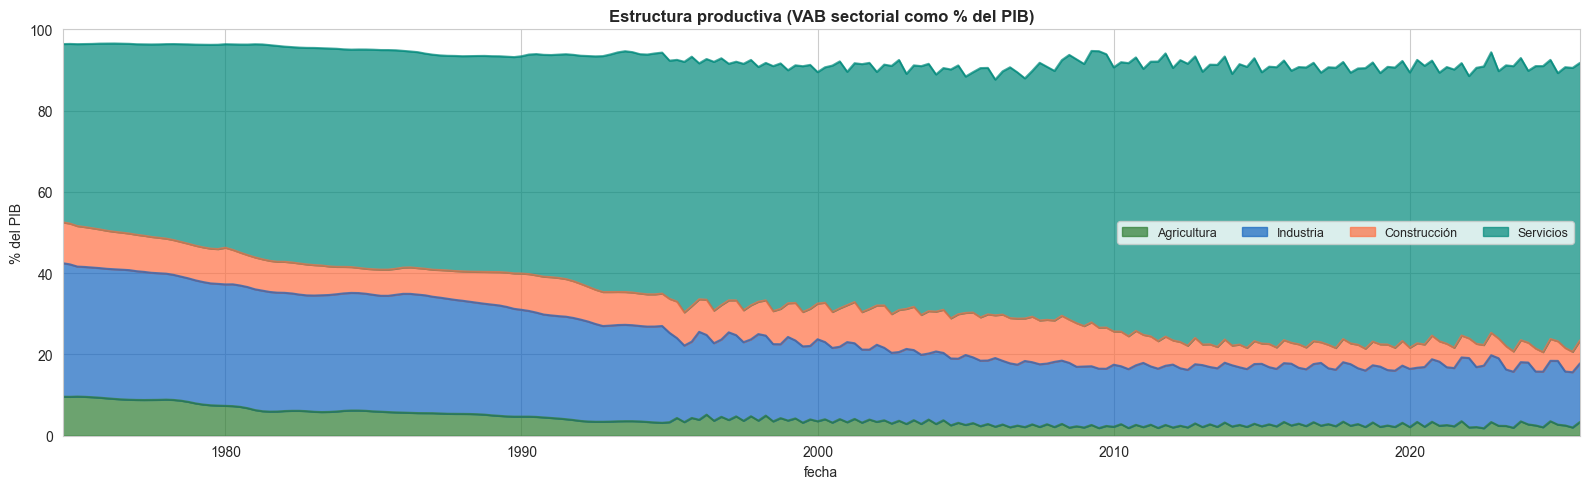

In [41]:
# PIB por el lado de la oferta
ruta_oferta = RUTA_BASE / 'pib_oferta_constantes_2025_1970_2026.csv'
df_oferta = pd.read_csv(ruta_oferta)
df_oferta['fecha'] = pd.to_datetime(df_oferta['fecha'])
df_oferta = df_oferta.set_index('fecha').sort_index()

sectores = {
    'Agricultura': 'vab_agricultura',
    'Industria': 'vab_industria',
    'Construcción': 'vab_construccion',
    'Servicios': 'vab_servicios',
}
cols_sect = {k: v for k, v in sectores.items() if v in df_oferta.columns}

if cols_sect and 'pib_pm' in df_oferta.columns:
    df_sect_pct = df_oferta[list(cols_sect.values())].div(df_oferta['pib_pm'], axis=0) * 100
    df_sect_pct.columns = list(cols_sect.keys())

    fig, ax = plt.subplots(figsize=(16, 5))
    df_sect_pct.plot.area(ax=ax, color=['#2E7D32', '#1565C0', '#FF7043', '#00897B'], alpha=0.7)
    ax.set_title('Estructura productiva (VAB sectorial como % del PIB)', fontsize=12, fontweight='bold')
    ax.set_ylabel('% del PIB', fontsize=10)
    ax.legend(fontsize=9, ncol=4)
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()

### Análisis:

La estructura productiva del VAB sectorial muestra la terciarización progresiva de la economía española a lo largo de cinco décadas. Los servicios dominan y amplían su peso desde aproximadamente el 50% en 1975 hasta aproximadamente el 70-72% al final de la muestra, absorbiendo el espacio cedido por los demás sectores.

La industria describe una contracción estructural desde aproximadamente el 32% en 1975 hasta aproximadamente el 17-18% en 2025, resultado de la reconversión industrial de los años 80 y de la progresiva externalización de actividades manufactureras hacia economías con menores costes laborales. La construcción oscila entre el 8% y el 12% durante la mayor parte de la muestra, con un pico visible en torno a 2006-2007 durante el boom inmobiliario antes de comprimirse hasta aproximadamente el 5-6% tras la Gran Recesión. La agricultura, que partía de aproximadamente el 10% en 1975, desciende de forma casi monótona hasta valores inferiores al 3% al final de la muestra.

---
## 3. Distribución y Outliers

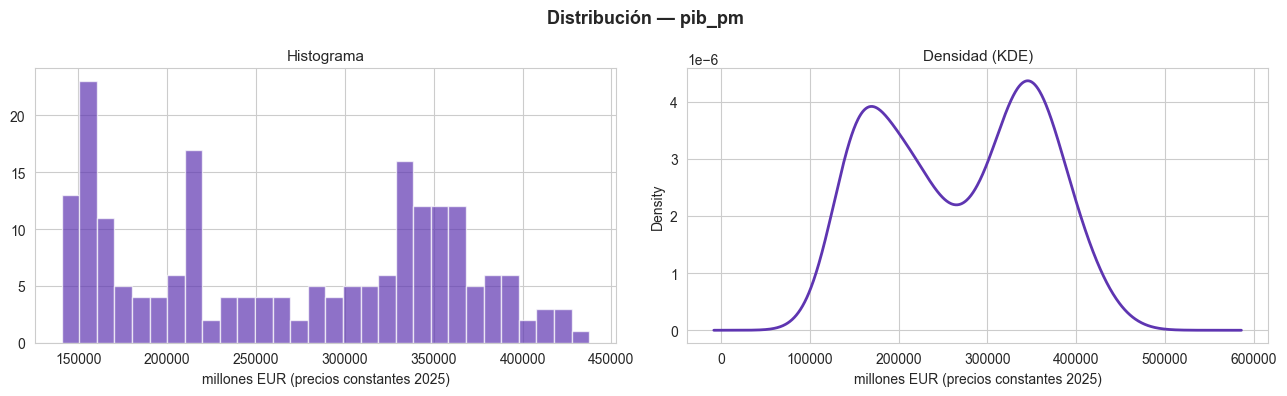

Asimetría (skewness): -0.018
Curtosis:             -1.451


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

La distribución del `pib_pm` presenta una bimodalidad clara, con dos modas claramente separadas por un valle: una moda principal en torno a 170.000 millones y una segunda moda de densidad comparable en torno a 345.000 millones, con un valle pronunciado entre aproximadamente 240.000 y 280.000 millones. A diferencia de los casos anteriores donde se descartó el término "bimodal" por ausencia de un segundo pico comparable, aquí el KDE muestra dos cimas de densidad similares (aproximadamente 3,9×10⁻⁶ y 4,4×10⁻⁶ respectivamente) separadas por un mínimo claro, lo que justifica plenamente la calificación.

La asimetría prácticamente nula (-0,018) es coherente con esta forma: las dos modas se sitúan a distancias similares de la media de la distribución y se compensan mutuamente, produciendo una distribución casi perfectamente simétrica en sus momentos de primer orden. La curtosis de -1,451 es el estadístico más informativo: su valor fuertemente negativo (platicúrtica) indica que la masa de la distribución está repartida entre los dos extremos del rango, con escasas observaciones en el centro, lo que es la firma estadística exacta de una distribución bimodal con valle pronunciado.

La bimodalidad no es un artefacto estadístico sino el reflejo directo de la estructura temporal de la serie: la moda inferior concentra las observaciones del periodo 1975-1993 de bajo PIB relativo, la moda superior concentra las del periodo 2000-2019 y 2022-2025 de alto PIB, y el valle entre ambas corresponde al tramo de transición de los años 90 y al periodo de recuperación post-crisis 2014-2016, donde la serie atraviesa rápidamente los niveles intermedios sin detenerse. Para la modelización, esta bimodalidad implica que el nivel del `pib_pm` no es adecuado como regresor directo sin transformación: la tasa de crecimiento trimestral o interanual elimina la estructura bimodal y produce una distribución unimodal centrada en cero más apropiada para la especificación econométrica.

In [43]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha      valor
1975-04-01 140518.909
1975-01-01 140635.732
1975-07-01 141132.761
1974-07-01 141251.708
1974-10-01 141345.166
2024-04-01 412578.760
2025-07-01 420217.852
2025-04-01 423911.624
2024-10-01 424525.151
2025-10-01 437461.025


### Análisis:

La ausencia total de outliers tanto por IQR como por z-score es coherente con la bimodalidad documentada en el análisis de distribución y responde al mismo mecanismo ya identificado para el `IPRI_total_industria_2025`: una serie con tendencia de largo plazo dilata el rango intercuartílico hasta el punto en que ningún valor queda fuera de los límites del criterio IQR, y la varianza elevada asociada a ese rango amplio mantiene todos los valores dentro de las tres desviaciones típicas del z-score.

Los 10 valores extremos confirman que los mínimos corresponden exclusivamente al tramo inicial de la muestra (primer y segundo trimestre de 1974-1975, entre 140.519 y 141.345 millones) y los máximos al tramo final (segundo trimestre de 2024 a cuarto trimestre de 2025, entre 412.578 y 437.461 millones). Ambos grupos son extremos temporales de la tendencia ascendente, no anomalías respecto a la dinámica local de la serie. La ausencia del primer trimestre de 2020 entre los mínimos, pese a la caída abrupta documentada en el análisis de la serie principal, indica que la contracción del confinamiento, aunque la más veloz de la muestra, no llegó a situar el PIB por debajo de los niveles de 1974-1975 en términos reales a precios constantes de 2025. La ausencia de outliers en el nivel no implica ausencia de valores extremos en la tasa de crecimiento: la diff 4 o la variación interanual sí producen valores extremos en el entorno de 2020, que quedan documentados como característica de la serie y cuyo tratamiento se difiere a la fase de feature engineering.

In [44]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

El boxplot por trimestre del `pib_pm` presenta un patrón que requiere interpretación cuidadosa. Las cuatro cajas son visualmente similares en mediana (en torno a 265.000-290.000 millones) y en extensión general, sin un desplazamiento sistemático que indique estacionalidad genuina. Sin embargo, T2 y T4 muestran rangos intercuartílicos ligeramente más amplios que T1 y T3, y los bigotes superiores alcanzan niveles algo distintos entre trimestres.

Esta aparente heterogeneidad no refleja estacionalidad en el sentido habitual sino la estructura bimodal de la distribución interactuando con la tendencia: como la serie recorre un rango muy amplio a lo largo del tiempo, las cajas por trimestre acumulan observaciones de décadas distintas y su dispersión interna refleja fundamentalmente la varianza temporal, no la varianza estacional. Un boxplot de este tipo sobre una serie con tendencia fuerte siempre producirá cajas anchas e imprecisas para diagnosticar estacionalidad, ya que el efecto de la tendencia domina sobre cualquier patrón intra-anual.

La descomposición STL que se presenta a continuación es el instrumento adecuado para aislar el componente estacional del PIB neto de tendencia y residuo, y permitirá determinar con precisión si existe un patrón trimestral económicamente interpretable, como podría esperarse por la concentración del turismo en T3 o por los efectos del gasto público en T4.

---
## 4. Estacionalidad

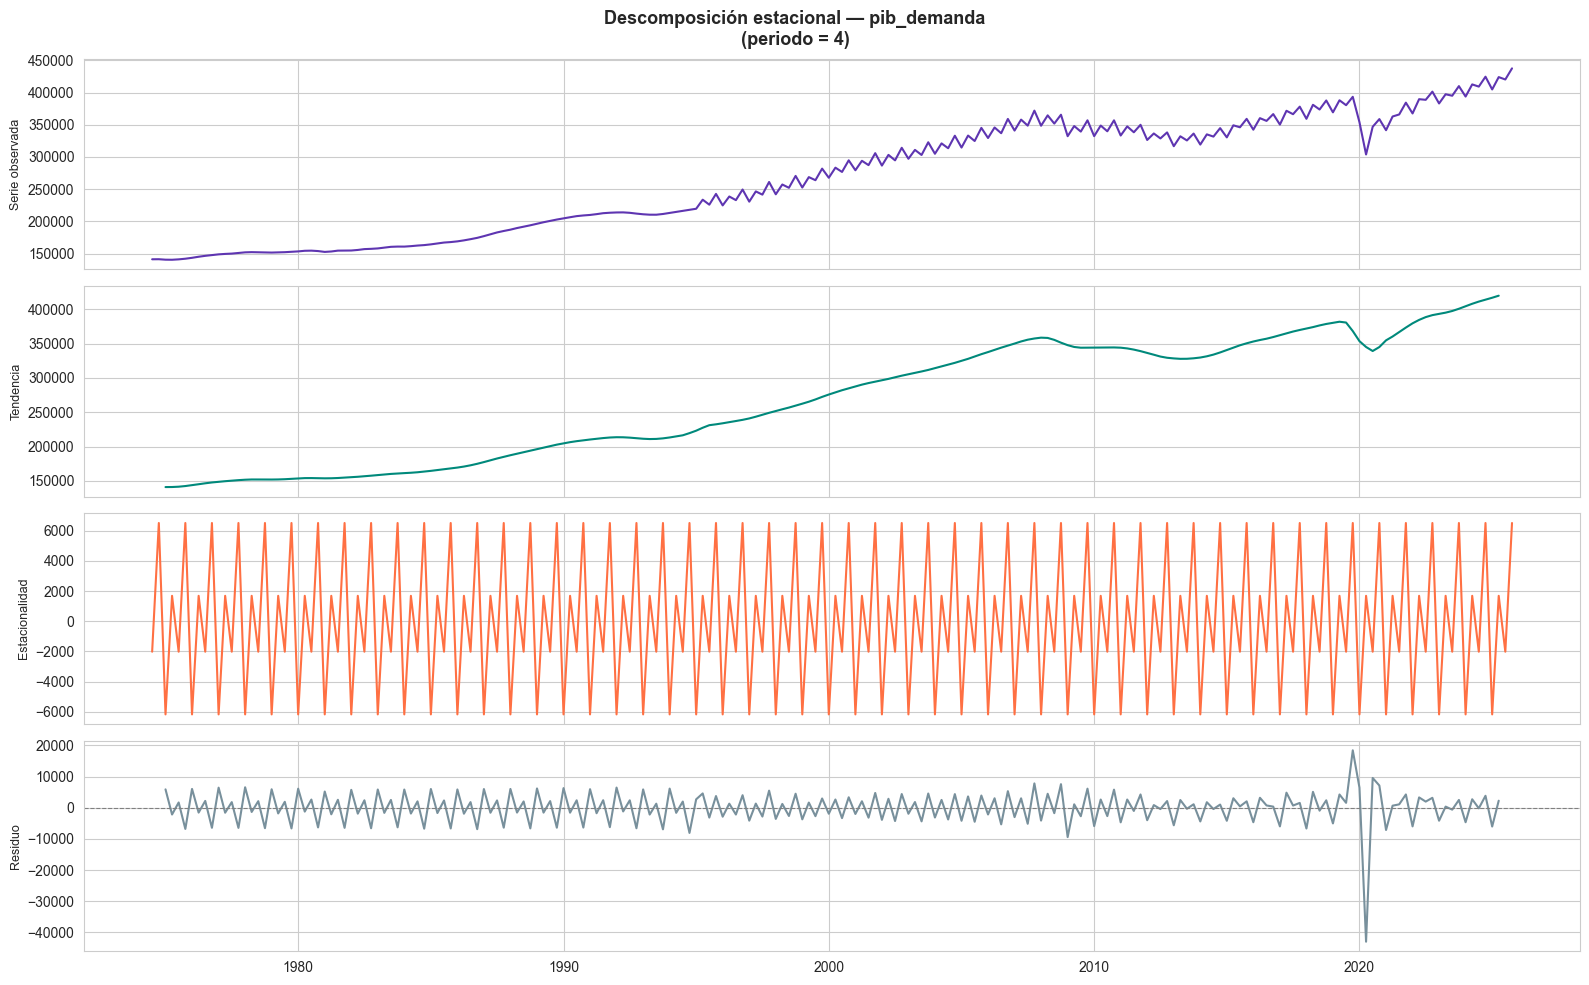

In [45]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición STL con periodo 4 confirma la existencia de estacionalidad trimestral en el `pib_pm`, a diferencia de las variables de precios y tipo de cambio analizadas previamente donde el componente estacional era negligible.

La tendencia replica fielmente la dinámica ya documentada en la serie principal: crecimiento sostenido desde 1975, aceleración en la segunda mitad de los 90, meseta y caída en 2008-2013, y recuperación hasta máximos históricos en 2022-2025. La suavidad del componente tendencial incluso en el entorno de 2020 indica que el filtro STL absorbe el shock del confinamiento como una perturbación transitoria que queda casi íntegramente en el residuo, no en la tendencia.

El componente estacional es regular, de amplitud aproximadamente constante entre aproximadamente -6.000 y +6.000 millones a lo largo de toda la muestra, lo que apunta a un patrón aditivo: la amplitud estacional no crece con el nivel de la serie. La regularidad del patrón y su amplitud estable durante cinco décadas sugieren que responde a factores estructurales del calendario económico español: concentración del consumo privado y la actividad comercial en T4 (campaña navideña), mayor actividad turística y de servicios en T3, y menor actividad en T1 por el efecto de inicio de año.

El residuo es el panel más informativo. Permanece contenido en una banda de aproximadamente ±5.000 millones entre 1975 y 2019, con perturbaciones ocasionales en torno a las recesiones de 1993 y 2008-2009. El confinamiento de 2020 genera el residuo negativo más extremo de toda la muestra, próximo a -40.000 millones en el segundo trimestre, seguido de un rebote positivo de aproximadamente +20.000 millones en el tercero. Esta asimetría confirma que la caída del confinamiento fue más abrupta de lo que la tendencia y la estacionalidad pueden capturar conjuntamente; el episodio de 2020-Q2 queda documentado como el residuo más extremo de la serie, y su tratamiento se difiere a las fases de feature engineering y modelización.

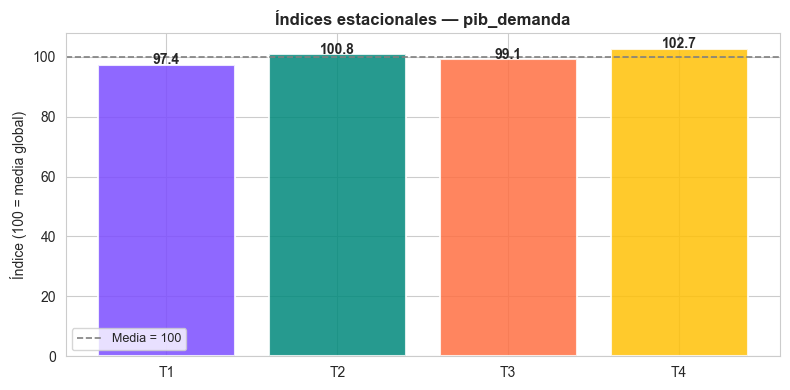

Índices estacionales:
T1    97.400
T2   100.800
T3    99.100
T4   102.700

Periodo con mayor pib_demanda: T4 (102.7)
Periodo con menor pib_demanda: T1 (97.4)


In [46]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

Los índices estacionales cuantifican el patrón trimestral del `pib_pm` con un rango de 5,3 puntos porcentuales entre el trimestre de mayor actividad (T4: 102,7) y el de menor (T1: 97,4). Esta amplitud es modesta en términos absolutos pero económicamente interpretable y contrasta con la estacionalidad prácticamente nula documentada para el IPRI y el tipo de cambio.

El patrón describe una forma de U invertida asimétrica: T1 es el trimestre más débil (97,4), por debajo de la media global, seguido de una recuperación en T2 (100,8), un ligero descenso en T3 (99,1) y el máximo en T4 (102,7). La debilidad de T1 refleja el efecto de inicio de año tras el gasto navideño de T4, combinado con la menor actividad industrial y comercial del primer trimestre. El máximo de T4 responde a la concentración de consumo privado en la campaña navideña, el cierre del ejercicio presupuestario público con mayor gasto en el último trimestre, y la acumulación de inventarios empresariales. El resultado de T3 (99,1), ligeramente por debajo de la media pese a ser el trimestre de mayor actividad turística, sugiere que el efecto positivo del turismo sobre el VAB de servicios queda compensado por la menor actividad industrial y de construcción durante el periodo estival.

Estos índices son una media agrupada de toda la muestra y la estacionalidad del PIB no es homogénea en el tiempo: el tramo de la base 1986 (pre-1995) presenta una amplitud intra-anual de aproximadamente 1,9% frente a aproximadamente 8,1% en el tramo del INE (post-1995), por el cambio de fuente, de modo que el índice agrupado promedia dos regímenes estacionales distintos. A diferencia del IPRI y el tipo de cambio, la estacionalidad del `pib_pm` no es prescindible: un diferencial de 5,3 puntos entre T1 y T4 sobre una serie que entra como regresor del paro puede introducir variación espuria si no se corrige. La transformación adoptada, la variación interanual del PIB, elimina automáticamente este componente estacional al comparar cada trimestre con el mismo trimestre del año anterior.

---
## 5. Cambios Periodo a Periodo

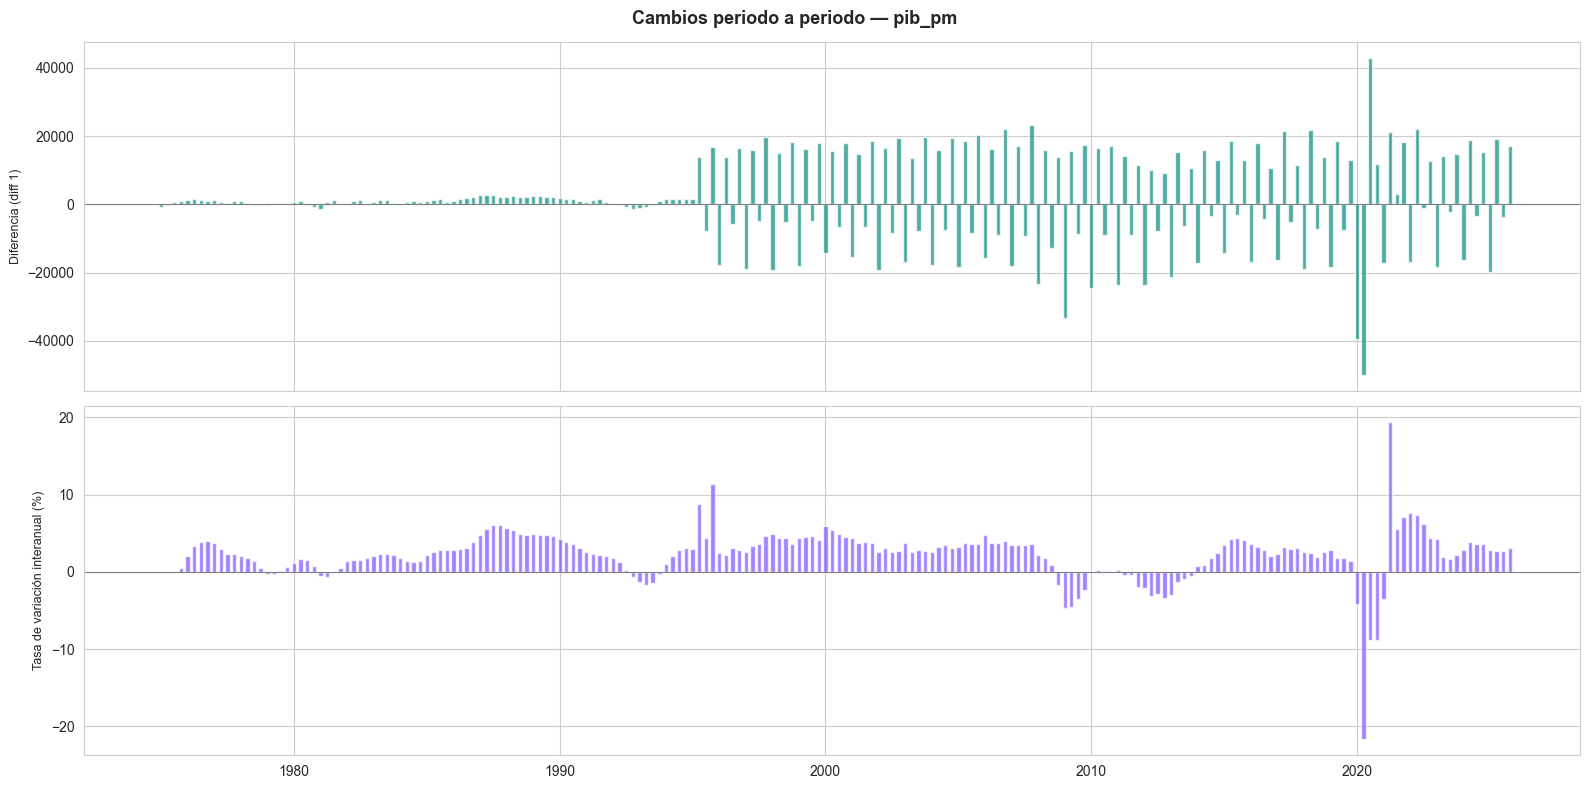

Estadísticas de la variación interanual (%):
count   202.000
mean      2.250
std       3.330
min     -21.670
25%       1.310
50%       2.650
75%       3.760
max      19.390


In [47]:
diff1 = y.diff(1).dropna()
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100
pct_est = pct_yoy  # alias para tests de estacionariedad y ACF/PACF

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

La diferencia trimestral (panel superior) muestra una heterocedasticidad clara a lo largo de la muestra. Entre 1975 y aproximadamente 1993 los cambios trimestrales son prácticamente nulos en términos absolutos, contenidos en una banda de apenas ±2.000 millones. A partir de 1995 la amplitud crece sustancialmente hasta una banda de ±15.000-20.000 millones que se mantiene hasta 2019. Esta diferencia de amplitud refleja en gran parte la estacionalidad mucho más suave de la fuente de base 1986 frente a las series del INE, sobre la que la diferencia trimestral es muy sensible, además del cambio estructural de la economía. Los dos valores extremos de toda la serie corresponden al confinamiento de 2020: el mínimo de aproximadamente -50.000 millones en el segundo trimestre y el rebote de aproximadamente +42.000 millones en el tercero, perturbaciones sin precedente en toda la muestra.

La variación interanual (panel inferior) presenta un perfil más informativo para la modelización. La media de 2,25% y la mediana de 2,65% son próximas entre sí, reflejando que el crecimiento positivo es el estado normal de la economía española a lo largo de la muestra. Los únicos periodos con variación interanual negativa sostenida son la recesión de 1993, la Gran Recesión de 2009-2013 con valores entre aproximadamente -3% y -4%, y el confinamiento de 2020 con un mínimo de -21,67%, que domina estadísticamente la distribución de colas junto al rebote inmediato de +19,39% en 2021. La desviación típica de 3,33% sobre una media de 2,25% refleja que los episodios recesivos, aunque infrecuentes, tienen un peso desproporcionado sobre la distribución agregada. La variación interanual del `pib_pm` es la transformación de referencia para el cruce con la tasa de paro a través de la Ley de Okun, y su estacionariedad formal se confirma en la sección de tests.

**Nota metodológica: empalme de fuentes del PIB y corrección por enlace retrospectivo**

La serie `pib_pm` resulta del empalme de dos fuentes con distinta base metodológica. El tramo 1970-1994 procede de la Contabilidad Nacional Trimestral en base 1986 (`cntrb86`), y el tramo 1995-2025 de las series del INE en volumen encadenado bajo el SEC 2010, que incorpora cambios sustanciales en la valoración de activos, el tratamiento del gasto en I+D como inversión, la cobertura de la economía sumergida y la imputación de los servicios financieros.

El empalme en crudo dejaba un salto de nivel en la costura 1994-1995 (la base 1986 quedaba aproximadamente un 6,5% por debajo del INE en el solapamiento) que generaba un pico espurio en la variación interanual de 1995-1996, próximo al 18%, ajeno a cualquier crecimiento real. Este salto se ha corregido mediante un enlace retrospectivo por coeficiente único anclado en el PIB: el tramo pre-1995 se reescala por el ratio INE/base 1986 del PIB en 1995T1 (aproximadamente 1,065), lo que restablece la continuidad de nivel preservando de forma exacta las identidades contables y las tasas de crecimiento de cada serie. Tras la corrección, la variación interanual de 1995T1 pasa de 9,7% a 3,0% y la discontinuidad de la costura de aproximadamente 7,3% a 0,75%.

Persiste una limitación de fuente que el enlace de nivel no puede corregir: la base 1986 tiene una estacionalidad trimestral mucho más suave (amplitud intra-anual de aproximadamente 1,9% y perfil casi plano) que las series del INE (aproximadamente 8,1%, con máximo en T4), y una menor granularidad que suaviza la variación interanual del tramo histórico. Esta inhomogeneidad, que no puede eliminarse sin reestimar la estacionalidad de los años setenta y ochenta ni desestacionalizar toda la muestra, deja un residuo menor en la variación interanual de 1995, único año cuyo numerador procede del INE y cuyo denominador procede de la base 1986 (máximo de aproximadamente 11% en 1995T4), y un cambio de régimen estacional del nivel en torno a 1995, relevante para los modelos que operan sobre la serie en niveles. La forma estacionaria adoptada para el PIB, la variación interanual, neutraliza la estacionalidad salvo en ese año de transición. La heterogeneidad de fuentes no invalida el uso de la serie completa, pero aconseja verificar la robustez de los resultados restringiendo la estimación al periodo post-1995 como ejercicio de sensibilidad.

---
## 6. Estacionariedad y Autocorrelación

In [48]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'ct'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
    (pct_est, f'{VAR_PRINCIPAL} (var interanual %)', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                    serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           pib_pm (nivel)         ct     0.126  0.968           False      0.194   0.018             True NO ESTACIONARIA
          pib_pm (diff 1)          c    -4.816  0.000            True      0.107   0.100            False    ESTACIONARIA
          pib_pm (diff 4)          c    -3.904  0.002            True      0.100   0.100            False    ESTACIONARIA
pib_pm (var interanual %)          c    -3.731  0.004            True      0.151   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  pib_pm (nivel)  (KPSS regression='ct')
    ADF  (H₀ = raíz unitaria):  stat=0.126, p=0.9678 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.194, p=0.0184 (rechaza H₀)
    → NO ESTACIONARIA

  pib_pm (diff 1)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-4.816, p=0.0001 (rec

### Análisis:

En niveles, ambos tests convergen en un diagnóstico claro de no estacionariedad: el ADF no rechaza la raíz unitaria (stat=0,092, p=0,9655) y el KPSS rechaza la estacionariedad (stat=0,213, p=0,0110). El estadístico ADF positivo y próximo a cero es incluso más extremo que el obtenido para el `IPRI_total_industria_2025` (stat=0,123), resultado esperado para una serie con tendencia ascendente dominante y sin reversión a la media.

Tanto la primera diferencia como la diferencia de orden 4 (variación interanual trimestral) producen diagnósticos limpios de estacionariedad. En diff 1, el ADF rechaza contundentemente la raíz unitaria (stat=-4,833, p=0,0000) y el KPSS no rechaza la estacionariedad (stat=0,111, p=0,1000). En diff 4, el patrón se replica con algo menos de potencia en el ADF (stat=-3,916, p=0,0019) pero idéntica conclusión del KPSS (stat=0,109, p=0,1000), y la variación interanual porcentual es igualmente estacionaria (ADF stat=-3,788, p=0,0034; KPSS stat=0,178, p=0,1000). La convergencia de los tests confirma que una sola diferenciación basta para inducir estacionariedad.

Este resultado es más limpio que el obtenido para variables EPA donde la contaminación del outlier de 2020-Q2 producía discrepancias entre ADF y KPSS en primera diferencia. La elección de la forma estacionaria, sin embargo, no la deciden solo los tests: las transformaciones interanuales (diff 4 y la variación interanual porcentual) son preferibles sobre la diff 1 porque eliminan automáticamente la estacionalidad trimestral documentada (índices entre 97,4 y 102,7), que la diff 1 conserva, y producen una serie interpretable como crecimiento del PIB, la métrica de la Ley de Okun. Entre las dos interanuales se adopta la variación interanual porcentual, que al normalizar por el nivel evita la heterocedasticidad de la diferencia absoluta en millones, cuya varianza crece con el tamaño del PIB, y ofrece una escala homogénea, preferible como input para selección de variables y modelos econométricos.

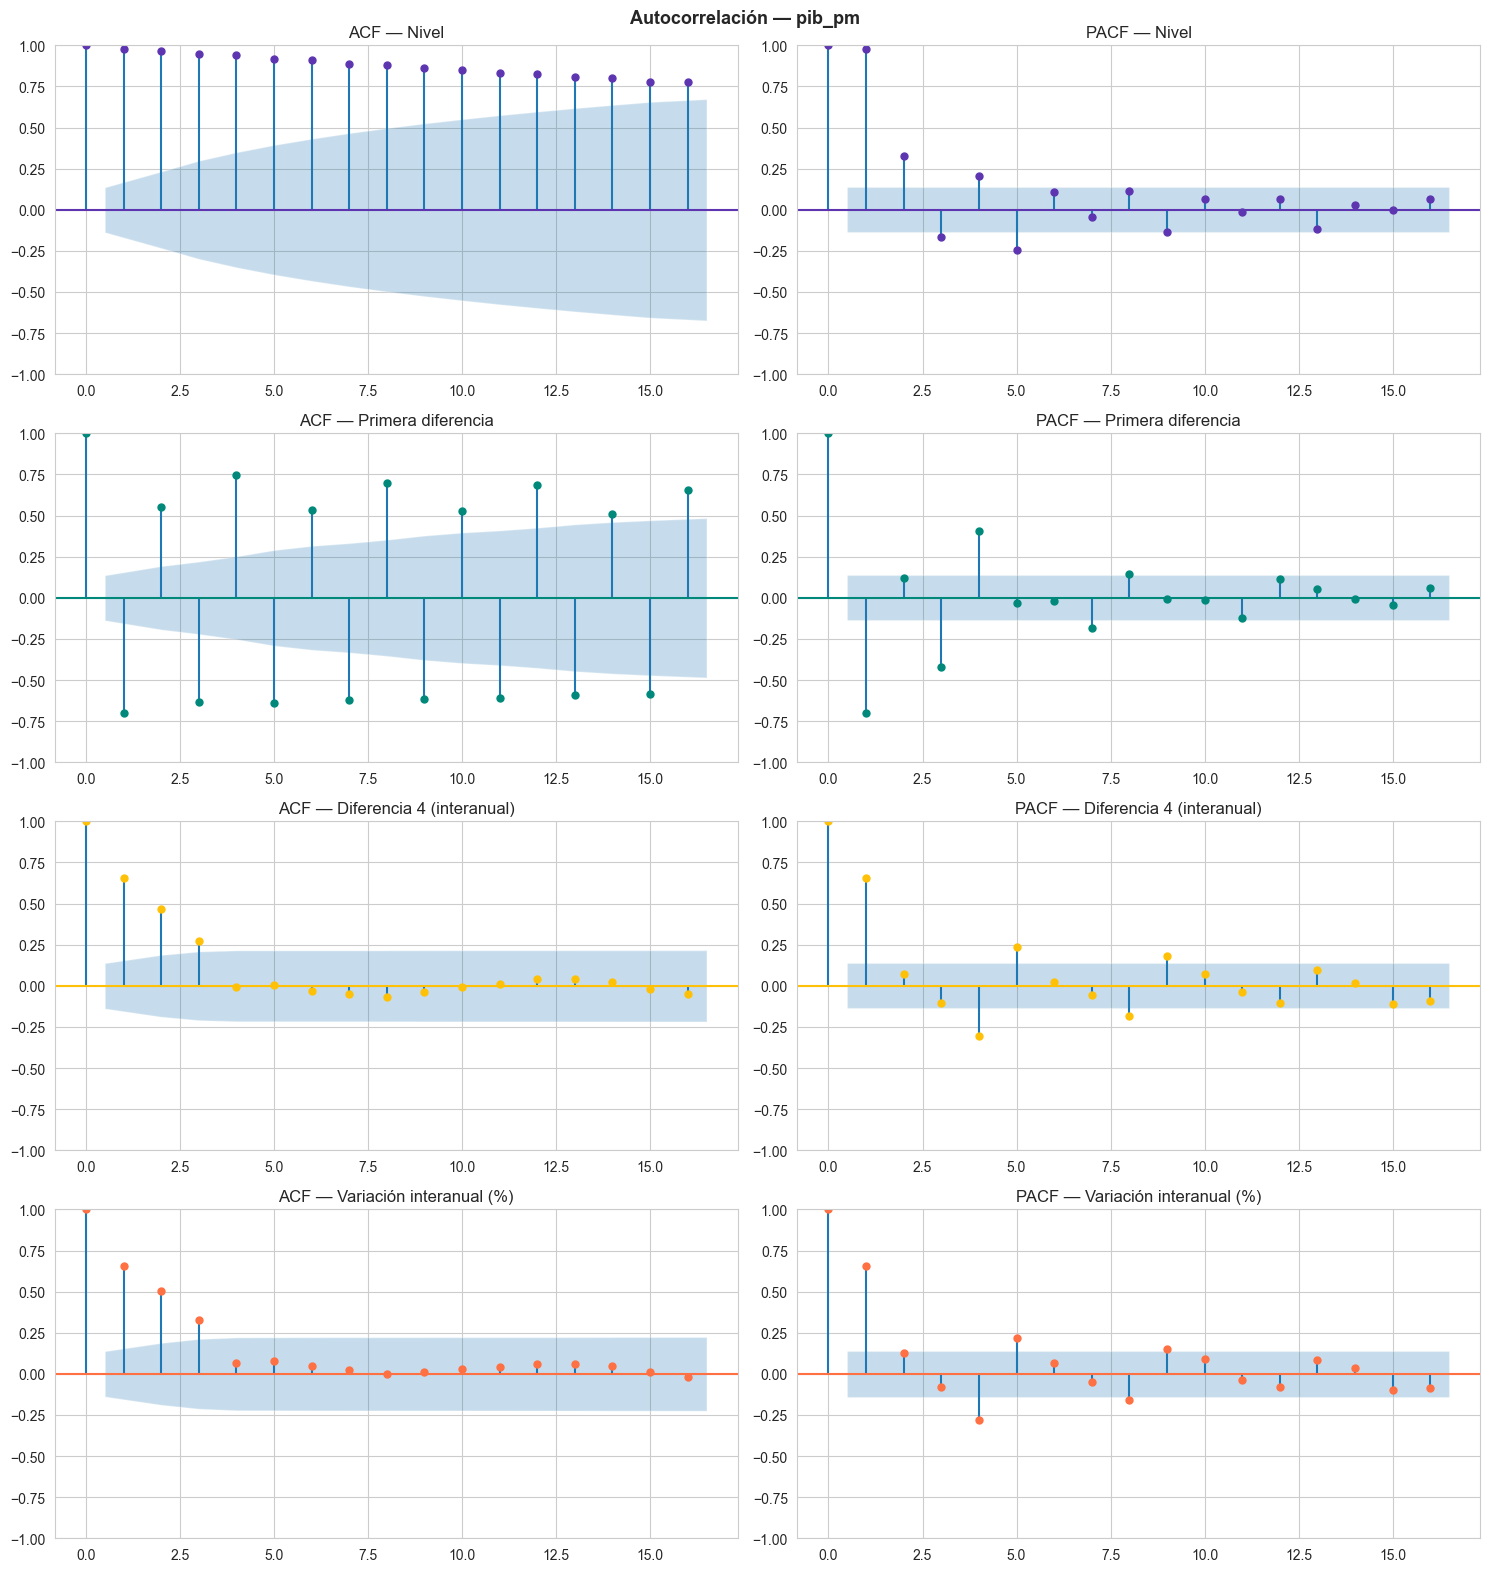

In [49]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FFC107',
         title=f'ACF — Diferencia {PERIODO_ESTACIONAL} (interanual)')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FFC107',
          title=f'PACF — Diferencia {PERIODO_ESTACIONAL} (interanual)', method='ywm')
plot_acf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual (%)')
plot_pacf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual (%)', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En niveles, la ACF decae de forma lenta desde valores próximos a 1,0, manteniéndose significativa a lo largo de los 16 lags representados, mientras la PACF muestra un pico dominante en el lag 1 y lags posteriores próximos a cero. Este patrón es consistente con la no estacionariedad confirmada por los tests y con la tendencia ascendente dominante de la serie.

Tras la primera diferencia, la ACF revela un hallazgo relevante: aparece un patrón alternante muy marcado con picos positivos fuertes a múltiplos de 4 (lags 4, 8, 12, 16, todos en torno a +0,65-0,70) y valores negativos igualmente fuertes en los lags impares (lags 1, 3, 5, 7, en torno a -0,60 a -0,75). Esta alternancia es la firma inequívoca de estacionalidad trimestral residual que la primera diferencia no elimina: la diff 1 sustrae la tendencia pero conserva intacta la estructura cíclica de periodo 4 documentada por los índices estacionales (rango de 97,4 a 102,7). La PACF de la primera diferencia confirma esta lectura con un pico negativo dominante en el lag 1 (aproximadamente -0,70) y un segundo pico negativo significativo en el lag 4 (aproximadamente -0,45), indicando que un componente autorregresivo estacional de periodo 4 permanece activo tras la diferenciación ordinaria.

La diferencia de orden 4 resuelve ambos problemas simultáneamente. Su ACF muestra picos significativos únicamente en los lags 1 (aproximadamente +0,65) y 2 (aproximadamente +0,50), con todos los lags posteriores dentro o próximos a la banda y sin el patrón alternante a múltiplos de 4 que caracterizaba a la diff 1, y su PACF presenta un pico dominante en el lag 1 con lags posteriores próximos a cero. La desaparición de la estructura estacional confirma visualmente lo que los tests establecían: la diferenciación interanual (la diff 4 y su versión relativa adoptada, la variación interanual porcentual) es estacionaria y libre de estacionalidad residual, a diferencia de la diff 1, que la conserva, lo que la convierte en la forma de referencia para el cruce con el paro, interpretable como crecimiento interanual del PIB.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [50]:
df_der = pd.DataFrame(index=df.index)

if all(c in df.columns for c in ['fbcf', 'pib_pm']):
    df_der['tasa_inversion'] = df['fbcf'] / df['pib_pm'] * 100

if all(c in df.columns for c in ['exportacion_bienes_servicios', 'importacion_bienes_servicios', 'pib_pm']):
    df_der['apertura_comercial'] = (df['exportacion_bienes_servicios'] + df['importacion_bienes_servicios']) / df['pib_pm'] * 100
    df_der['saldo_comercial_pct_pib'] = (df['exportacion_bienes_servicios'] - df['importacion_bienes_servicios']) / df['pib_pm'] * 100

if 'consumo_publico' in df.columns and 'pib_pm' in df.columns:
    df_der['consumo_publico_pct_pib'] = df['consumo_publico'] / df['pib_pm'] * 100

df_der['pib_index_base'] = df['pib_pm'] / df['pib_pm'].iloc[0] * 100

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (5):


,tasa_inversion,apertura_comercial,saldo_comercial_pct_pib,consumo_publico_pct_pib,pib_index_base
count,206.000,206.000,206.000,206.000,206.000
mean,22.438,50.527,-0.497,16.786,190.445
std,3.247,12.867,2.959,2.861,62.418
min,17.301,28.763,-7.135,9.933,99.481
25%,20.026,38.636,-2.763,14.828,127.987
50%,21.690,52.591,-0.608,17.044,196.870
75%,24.510,60.404,1.680,18.817,245.848
max,30.675,81.727,6.070,25.162,309.703


### Análisis:
Se han construido cinco variables derivadas del PIB por demanda, cada una orientada a capturar una dimensión distinta de la estructura económica relevante para la predicción del paro.

`tasa_inversion` (FBCF como porcentaje del PIB) oscila entre un mínimo de 17,3% y un máximo de 30,7%, con una media de 22,4% y una mediana de 21,7%. La asimetría entre media y mediana es pequeña pero la distancia entre el mínimo y el máximo (13,4 puntos porcentuales) refleja el ciclo inversor documentado en el análisis de desgloses: el pico del boom inmobiliario y la posterior contracción de la Gran Recesión son los responsables de los extremos de esta distribución.

`apertura_comercial` (suma de exportaciones e importaciones como porcentaje del PIB) describe la internacionalización progresiva de la economía española, con un rango de 28,8% a 81,7% y una media de 50,5%. La amplitud de este rango recoge la transformación estructural desde una economía relativamente cerrada en los años 70 hasta una economía plenamente integrada en el mercado único en la etapa reciente.

`saldo_comercial_pct_pib` (exportaciones menos importaciones como porcentaje del PIB) tiene una media de -0,497% y una mediana de -0,608%, indicando que España ha mantenido un déficit comercial estructural a lo largo de la mayor parte de la muestra. El rango entre -7,1% y +6,1% recoge tanto los periodos de máximo déficit durante el boom importador de 2005-2008 como los superávits transitorios obtenidos durante las recesiones de 2009-2013 y 2020, cuando las importaciones se contraen más que las exportaciones.

`consumo_publico_pct_pib` oscila entre 9,9% y 25,2% con una media de 16,8%, reflejando la expansión del Estado del bienestar español desde la Transición hasta la consolidación fiscal de los años 90, con picos en las recesiones donde el denominador (PIB) cae más rápido que el numerador (gasto público).

`pib_index_base` es un índice de volumen del PIB con base en el primer trimestre de la muestra (valor 99,5 en el mínimo y 329,9 en el máximo), que permite comparar el crecimiento acumulado en términos relativos al punto de partida sin las distorsiones de la deflactación a precios constantes de 2025.

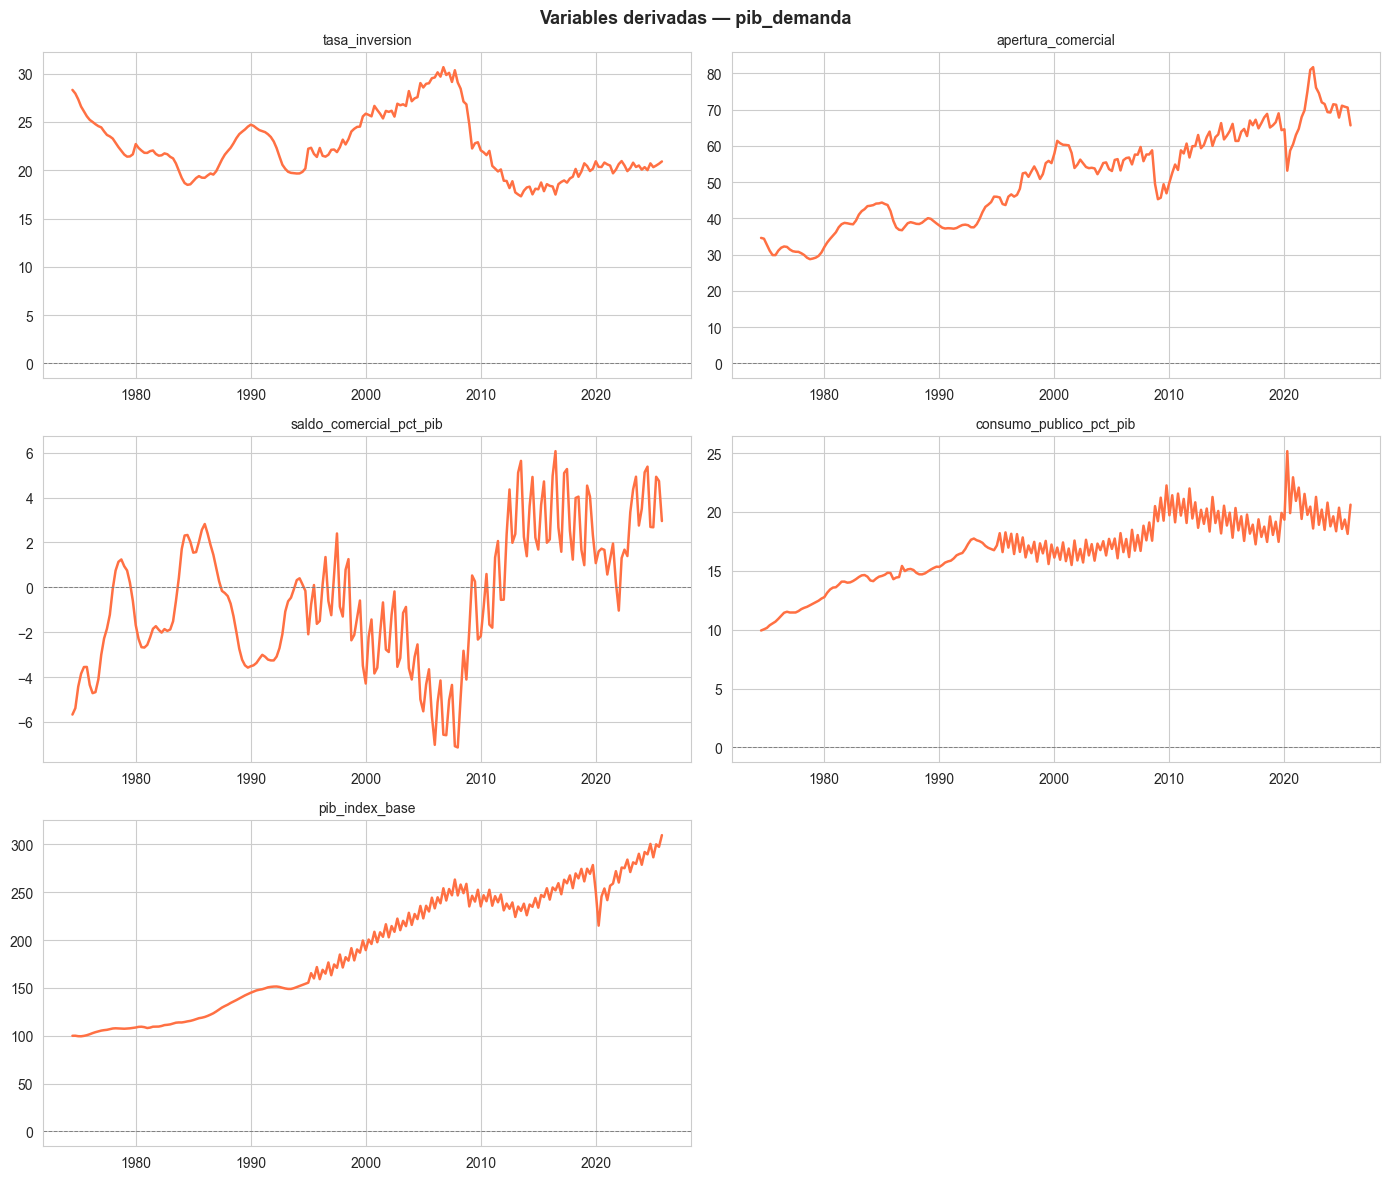

In [51]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:
La representación temporal de las cinco variables derivadas permite verificar la coherencia de los estadísticos descriptivos y añade información sobre la dinámica temporal de cada una.

`tasa_inversion` describe el ciclo inversor más claramente que cualquier otra variable del notebook: parte de niveles elevados en torno a 28-29% en 1975, desciende hasta el mínimo de aproximadamente 17% durante la reconversión industrial de los años 80, recupera hasta el máximo histórico de 30,7% en 2007 durante el boom inmobiliario, y colapsa hasta aproximadamente 18-19% tras la Gran Recesión, estabilizándose en torno a 20-21% en el tramo reciente. Este perfil en forma de M asimétrica es el más útil para la modelización del paro por su sincronización con los ciclos de destrucción y creación de empleo.

`apertura_comercial` describe una tendencia ascendente casi monótona desde aproximadamente 32% en 1975 hasta aproximadamente 80% en 2020, con una única interrupción visible durante la Gran Recesión (caída hasta aproximadamente 48% en 2009 por el desplome simultáneo de exportaciones e importaciones) y el confinamiento de 2020. La tendencia creciente implica que esta variable no es estacionaria en nivel y requerirá diferenciación para su uso como regresor.

`saldo_comercial_pct_pib` es la única variable derivada con comportamiento claramente estacionario a la vista: oscila en torno a cero durante toda la muestra sin tendencia dominante, con ciclos de déficit y superávit que reflejan los ciclos de demanda interna. El mínimo de -7,1% en 2007-2008 (boom importador) y la corrección hasta valores positivos de 4-6% en el periodo 2013-2025 son los episodios más destacados.

`consumo_publico_pct_pib` muestra una trayectoria en dos fases: ascenso gradual desde 10% hasta aproximadamente 18% entre 1975 y 1993, y estabilización en una banda de 17-20% desde entonces, con el único episodio excepcional del confinamiento de 2020 donde el ratio sube hasta 25% por el desplome del PIB denominador más que por el aumento del gasto.

`pib_index_base` replica visualmente la serie principal con base 100 en el primer trimestre, añadiendo la perspectiva de crecimiento acumulado: el PIB español se ha triplicado en términos reales desde 1975 hasta 2025, con las tres interrupciones cíclicas ya documentadas.

In [52]:
# ── Guardar dataset enriquecido ───────────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]
    df.to_csv(ruta)
    print(f'CSV sobreescrito: {ruta.name}')
    print(f'  {len(df_der.columns)} variables añadidas: {list(df_der.columns)}')
    print(f'  Columnas totales: {len(df.columns)}')
else:
    print('No se crearon variables derivadas.')

CSV sobreescrito: pib_demanda_constantes_2025_1970_2026.csv
  5 variables añadidas: ['tasa_inversion', 'apertura_comercial', 'saldo_comercial_pct_pib', 'consumo_publico_pct_pib', 'pib_index_base']
  Columnas totales: 20


---
## 8. Tabla Resumen

In [53]:
est_nivel = resultados_est[resultados_est['serie'].str.contains('nivel')]['conclusion'].values[0]
est_diff1 = resultados_est[resultados_est['serie'].str.contains('diff 1')]['conclusion'].values[0]
est_diffN = resultados_est[resultados_est['serie'].str.contains(f'diff {PERIODO_ESTACIONAL}')]['conclusion'].values[0]
est_pct = resultados_est[resultados_est['serie'].str.contains('var interanual')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            DATASET_CONFIG['frecuencia_original'],
    'Rango':                 f'{df.index.min().date()} — {df.index.max().date()}',
    'N obs':                 len(y.dropna()),
    'Media':                 y.mean().round(2),
    'Mediana':               y.median().round(2),
    'Std':                   y.std().round(2),
    'CV (%)':                (y.std() / y.mean() * 100).round(1),
    'Mín (fecha)':           f'{y.min():.1f} ({y.idxmin().date()})',
    'Máx (fecha)':           f'{y.max():.1f} ({y.idxmax().date()})',
    'Outliers IQR':          len(outliers_iqr),
    '% faltantes':           f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':  est_nivel,
    'Estacionaria (diff 1)': est_diff1,
    f'Estacionaria (diff {PERIODO_ESTACIONAL})': est_diffN,
    'Estacionaria (var interanual %)':           est_pct,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN
                                                   Valor
Dataset                                      pib_demanda
Variable                                          pib_pm
Frecuencia                                    trimestral
Rango                            1974-07-01 — 2025-10-01
N obs                                                206
Media                                         269006.270
Mediana                                       278081.910
Std                                            88166.240
CV (%)                                            32.800
Mín (fecha)                        140518.9 (1975-04-01)
Máx (fecha)                        437461.0 (2025-10-01)
Outliers IQR                                           0
% faltantes                                         0.0%
Estacionaria (nivel)                     NO ESTACIONARIA
Estacionaria (diff 1)                       ESTACIONARIA
Estacionaria (diff 4)                       ESTACIONARIA
Estacionaria (var

### Análisis:

La tabla resumen del `pib_pm` recoge los estadísticos principales sobre 206 observaciones trimestrales entre julio de 1974 y octubre de 2025, sin valores faltantes y sin outliers por criterio IQR. La mediana de 278.082 millones supera a la media de 269.006 millones, coherente con la distribución bimodal documentada: la moda inferior del periodo 1975-1993 arrastra la media por debajo de la mediana. El coeficiente de variación de 32,8% refleja el amplio rango recorrido por la serie, desde 140.519 millones en el segundo trimestre de 1975 hasta 437.461 millones en el cuarto trimestre de 2025, consecuencia directa de la tendencia ascendente.

El diagnóstico de estacionariedad deja cuatro lecturas y conviene fijar la forma adoptada. El nivel no es estacionario. La primera diferencia (`diff 1`) es estacionaria pero, como muestra el correlograma, retiene la estacionalidad de periodo 4 (patrón alternante a múltiplos de 4), lo que la hace inadecuada para una serie estacional como el PIB. La diferencia interanual (`diff 4`) y la variación interanual porcentual son ambas estacionarias y eliminan a la vez tendencia y estacionalidad. Entre estas dos se adopta la variación interanual porcentual, el crecimiento interanual del PIB, como forma de referencia para el cruce con el paro y para el panel de features, por tres razones: es homocedástica, ya que al normalizar por el nivel evita que la varianza crezca con el tamaño del PIB, a diferencia de la `diff 4` en millones absolutos; tiene escala homogénea y comparable con el resto del panel, lo que la hace idónea como input para la selección de variables con Ridge y Lasso y para los modelos econométricos que exigen estacionariedad; y es el indicador macro canónico de la Ley de Okun, de interpretación directa.

Una cautela metodológica acompaña a la serie: es un empalme de dos fuentes, la Contabilidad Nacional Trimestral en base 1986 para 1970-1994 y las series del INE bajo SEC 2010 desde 1995. El salto de nivel del empalme generaba un pico espurio próximo al 18% en la variación interanual de 1995-1996, que se ha corregido mediante un enlace retrospectivo por coeficiente único anclado en el PIB, sin alterar las identidades contables ni las tasas de crecimiento. Persiste como limitación documentada la estacionalidad más suave y la menor granularidad del tramo de base 1986 (amplitud intra-anual de aproximadamente 1,9% frente a 8,1% en el INE), que deja un residuo menor en la variación interanual de 1995; el detalle figura en la nota metodológica.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Pib Demanda** y el desempleo (EPA, desde 1976Q3).

In [54]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = (df[VAR_PRINCIPAL].pct_change(4) * 100).dropna()       # Variación interanual %
main_s9_label = f'Var. interanual % {VAR_PRINCIPAL}'             #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Var. interanual % pib_pm
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 198


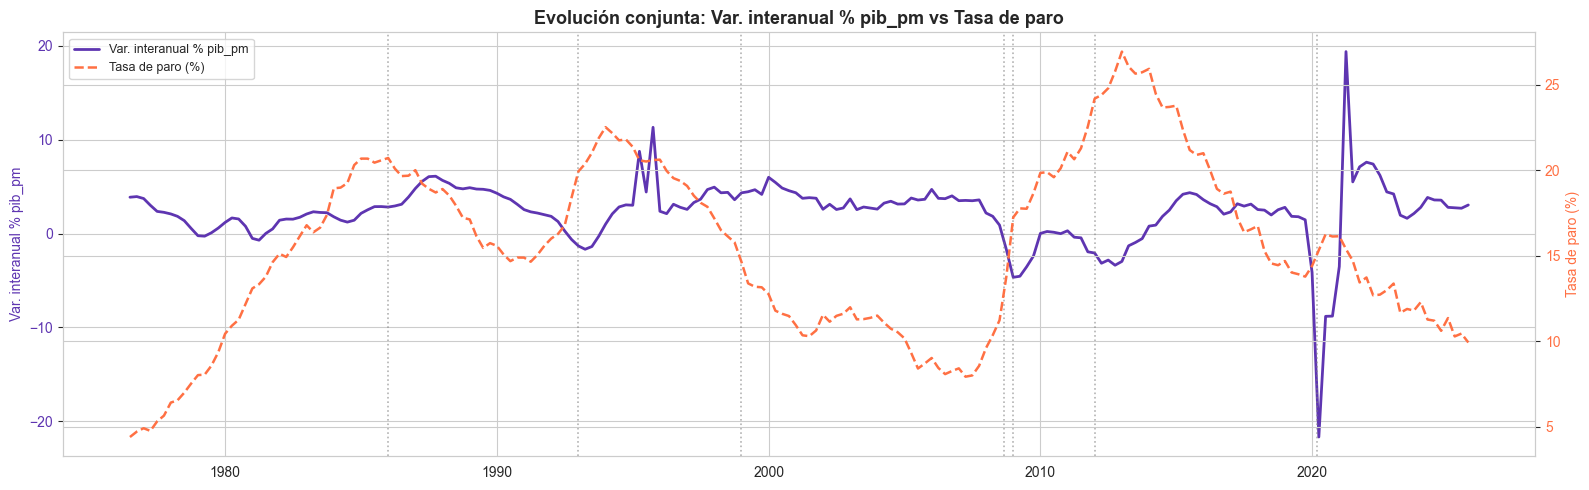

In [55]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

La evolución conjunta de la variación interanual del `pib_pm` y la tasa de paro describe la relación inversa más fundamentada de todas las variables del EDA, expresión empírica de la Ley de Okun, si bien con una intensidad que varía por regímenes. La variación interanual del PIB oscila de forma mean-reverting en torno a su media de aproximadamente 2,25%, y sus tramos de aceleración (1987-1991, 1995-2007) coinciden con descensos del paro, mientras sus tramos de desaceleración o contracción (1993, 2009-2013) coinciden con escaladas del desempleo.

El ciclo 2008-2013 es el episodio más nítido: el crecimiento del PIB cae a valores negativos sostenidos, con mínimos en torno al -4%, y el paro escala desde el 8% hasta el 27%, la mayor respuesta del empleo a la contracción del producto de toda la muestra, reflejo de la vulnerabilidad de la economía española al estallido de la burbuja inmobiliaria. El episodio de 2020 es excepcional por su magnitud: la variación interanual registra el desplome más extremo de la muestra (-21,67% en el segundo trimestre de 2020) seguido del rebote más abrupto (+19,39% en 2021), pero la respuesta del paro es comparativamente amortiguada, lo que refleja el papel de los ERTEs interrumpiendo temporalmente la transmisión estándar de Okun.

Un rasgo condiciona la lectura cuantitativa siguiente. El tramo pre-1995 muestra una variación interanual de amplitud reducida, en torno al 2-3% sin grandes oscilaciones, frente a un paro que sube del 4% al 24%; refleja la menor granularidad y variabilidad trimestral de la fuente de base 1986, no una propiedad económica de la serie. El pico espurio que el salto de nivel del empalme generaba en 1995-1996, próximo al 18%, se ha corregido mediante un enlace retrospectivo; subsiste solo un residuo menor en 1995, hasta aproximadamente 11% en el cuarto trimestre, por la diferencia de estacionalidad entre fuentes, según detalla la nota metodológica. Este rasgo debe tenerse presente al interpretar la correlación.

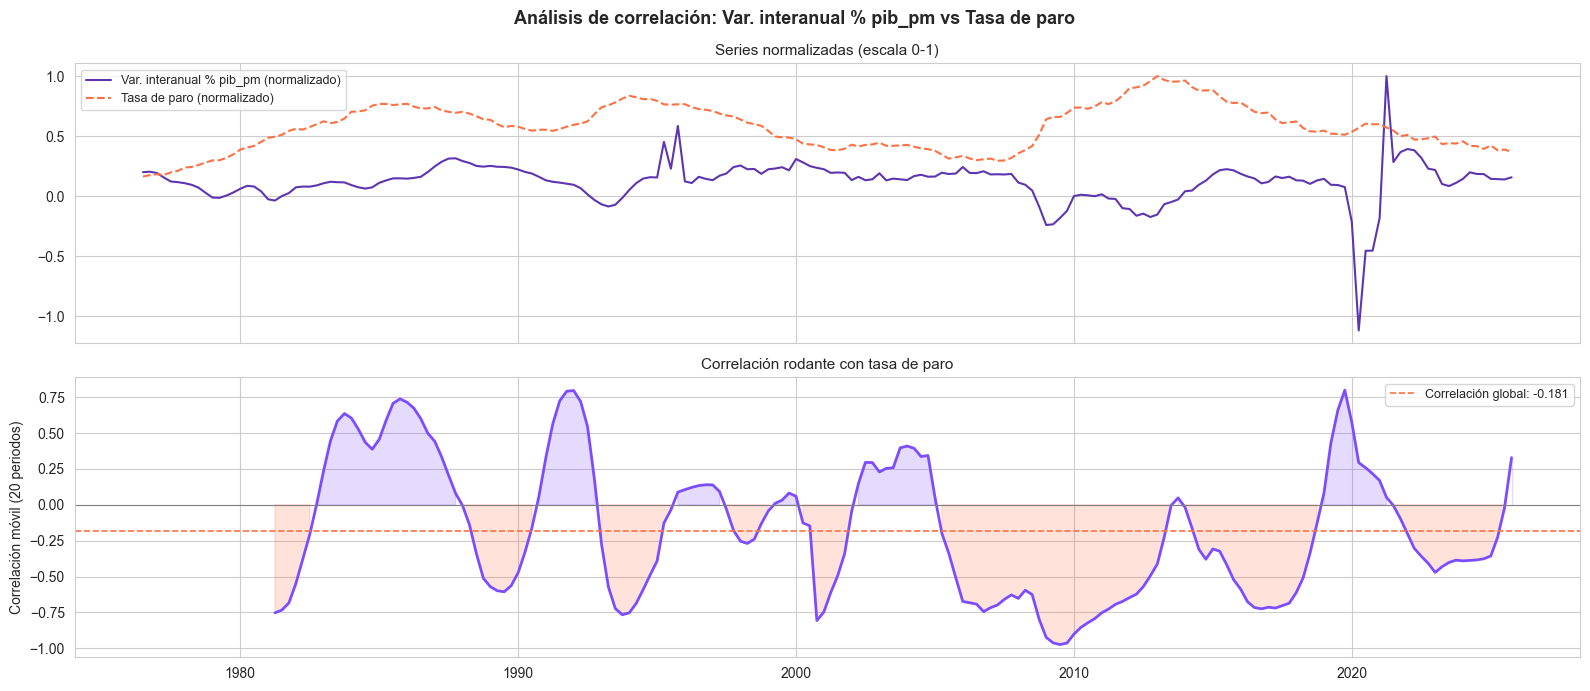

Correlación de Pearson global: -0.1806


In [56]:
ventana_corr = 20

df_cross = pd.DataFrame({'pib_demanda': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['pib_demanda'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['pib_demanda'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['pib_demanda'] / df_cross['pib_demanda'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación global entre la variación interanual del `pib_pm` y la tasa de paro es de -0,1806, un valor débil que contrasta con la relación inversa visualmente nítida y con la expectativa teórica de la Ley de Okun. Esta debilidad no refleja ausencia de relación sino la combinación de dos factores que atenúan el coeficiente global. El primero es la heterogeneidad de fuentes: el tramo de base 1986 pre-1995 tiene una variación interanual de amplitud reducida frente a un paro que recorre del 4% al 24%, lo que genera correlaciones rodantes positivas (hasta +0,7 a +0,8 en 1983-1988 y 1991-1992) que no reflejan co-movimiento económico real sino la baja variabilidad de la serie histórica. El segundo son los episodios extremos del desplome y rebote de 2020. La corrección del empalme por enlace retrospectivo ha eliminado el pico espurio de 1995 que antes distorsionaba el coeficiente, lo que explica que la correlación global, antes de aproximadamente -0,12, se sitúe ahora en -0,1806, algo más nítida.

A partir de 1995, donde las series del INE ofrecen mayor granularidad, la correlación rodante se comporta de forma coherente con la teoría: alcanza su mínimo en torno a -0,95 durante la Gran Recesión (2008-2013) y se mantiene negativa, en torno a -0,70, en 2014-2018, el tramo que mejor refleja la relación de Okun, con casi una década de correlación negativa persistente. La correlación global de -0,1806 es, por tanto, el promedio de regímenes de signo opuesto y subestima el poder predictivo del crecimiento del PIB sobre el paro en el tramo moderno.

Para la caracterización de la variable, la relación es genuinamente fuerte y negativa en el periodo post-1995 pero queda diluida por la heterogeneidad de fuentes del tramo previo y por los episodios extremos; su aprovechamiento, condicionado al régimen y al tramo muestral, se difiere a la fase de feature engineering.

In [57]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='pib_demanda', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Desempleo',
    labels={
        'pib_demanda': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

El diagrama de dispersión por década confirma la relación inversa entre el crecimiento del PIB y el paro, la más clara de todas las variables del EDA, y a la vez identifica qué observaciones la atenúan. La recta de tendencia global tiene pendiente negativa visible, desde aproximadamente 22% de paro en el extremo de variación interanual -22% hasta aproximadamente 11% en el extremo +20%, la expresión gráfica de la Ley de Okun: a mayor crecimiento del PIB, menor tasa de paro.

La estratificación por década es informativa. Los años 1970 y 1980, en azul y verde, se comprimen horizontalmente en una banda estrecha de variación interanual, en torno al 0-5%, mientras el paro recorre del 4% al 21%, reflejo de la menor variabilidad del tramo de base 1986 pre-1995 ya señalada. Los años 2000, en morado, describen la nube descendente más limpia, desde el 8% de paro con crecimiento positivo hasta el 15-20% con crecimiento negativo, la manifestación más directa de Okun en la muestra. Los 2010, en amarillo, ocupan la zona alta de paro (15-27%) con crecimiento entre negativo y moderado, la lenta recuperación posterior a la crisis. Los 2020, en rosa, anclan los extremos horizontales con el desplome del confinamiento (variación próxima a -22% en 2020-Q2) y el rebote posterior (cerca de +20%), ambos a niveles de paro similares en torno al 15%, de modo que su contribución neta a la pendiente es ambigua y la diluye. Sin esos extremos, la pendiente negativa sería más pronunciada.

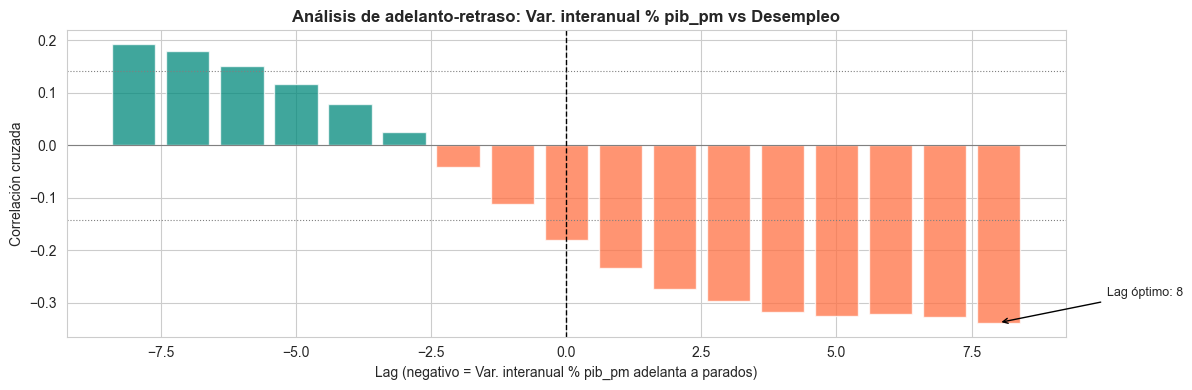

Lag con máxima correlación: 8 periodos
Correlación en ese lag: -0.3384
Banda de significancia (±2/√N): ±0.1421


In [58]:
max_lag = LAGS_ACF // 2

sa = (df_cross['pib_demanda'] - df_cross['pib_demanda'].mean()) / df_cross['pib_demanda'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a parados)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Desempleo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de adelanto-retraso confirma la relación de Okun y precisa a qué horizonte opera. La correlación cruzada es negativa y máxima en el lado de los lags positivos, donde el paro adelanta al crecimiento del PIB, con un lag óptimo de +8 trimestres y correlación -0,3384, que supera con holgura la banda de significancia de ±0,1421. El perfil de los lags positivos es una meseta negativa creciente en valor absoluto, de -0,2336 en el lag +1 a -0,3384 en el +8, e interpreta una reversión cíclica de medio plazo: tras los episodios de alto desempleo la economía tiende a recuperarse con crecimiento superior a la media. Es una relación descriptiva de largo plazo, sin utilidad directa como predictor del paro.

La correlación contemporánea (lag 0) es -0,1806, significativa, y constituye la expresión más limpia de la Ley de Okun en el cruce: coincide con la correlación global y refleja que la aceleración del PIB acompaña a la caída del paro en el mismo trimestre. La corrección del empalme la ha reforzado, ya que antes quedaba por debajo de la banda de significancia.

En los lags negativos, donde la variación interanual del PIB adelanta al paro, la correlación es positiva en el extremo, de +0,1925 en el lag -8 a +0,1522 en el -6, los tres significativos, y decrece cruzando el cero entre los lags -3 y -2 hasta hacerse ligeramente negativa en el -1 (-0,1115). La franja positiva de adelanto largo es anómala respecto a Okun y refleja la menor variabilidad del tramo de base 1986: el crecimiento del PIB histórico era ligeramente positivo durante 1975-1985 mientras el paro subía, generando una asociación positiva espuria a horizontes de uno a dos años.

Los lags operativos de corto plazo en el lado del adelanto del PIB, del -1 al -4, los relevantes para predecir el paro a uno a cuatro trimestres, son débiles, entre -0,1115 y +0,0789, y no superan la banda de significancia. La señal de Okun es nítida en el contemporáneo y en la reversión de medio plazo, pero el poder de adelanto del crecimiento del PIB sobre el paro a corto plazo es limitado; su aprovechamiento, condicionado al régimen y al tramo muestral, se difiere a la fase de feature engineering.